<a href="https://colab.research.google.com/github/saniyaverma/Crop-Disease-Prediction-Models-analysis/blob/main/Tomato_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import os, json, random, shutil
from zipfile import ZipFile
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

SEED = 123
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision ON")
except Exception as e:
    print("Mixed precision not available:", e)

Mixed precision ON


In [ ]:
# Load Kaggle credentials and download dataset
kaggle_credentials = json.load(open("kaggle.json"))
os.environ['KAGGLE_USERNAME'] = kaggle_credentials["username"]
os.environ['KAGGLE_KEY'] = kaggle_credentials["key"]

!kaggle datasets download -d kaustubhb999/tomatoleaf

# Unzip
with ZipFile("tomatoleaf.zip", 'r') as zip_ref:
    zip_ref.extractall()

Dataset URL: https://www.kaggle.com/datasets/kaustubhb999/tomatoleaf
License(s): CC0-1.0
tomatoleaf.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# Paths from the dataset
train_path = "/content/tomato/train"
val_path = "/content/tomato/val"

**Create a unified folder**

In [ ]:
# New unified folder
combined_path = "/content/tomato-leaf-disease"
os.makedirs(combined_path, exist_ok=True)

def combine_folders(source_dir, target_dir):
    for cls in os.listdir(source_dir):
        src_cls_path = os.path.join(source_dir, cls)
        dst_cls_path = os.path.join(target_dir, cls)
        os.makedirs(dst_cls_path, exist_ok=True)

        for file_name in os.listdir(src_cls_path):
            src_file = os.path.join(src_cls_path, file_name)
            dst_file = os.path.join(dst_cls_path, file_name)

            # Only copy if file doesn't already exist
            if not os.path.exists(dst_file):
                shutil.copy2(src_file, dst_file)

        print(f"Copied: {cls} from {source_dir} to {target_dir}")

# Combine all splits into one
combine_folders(train_path, combined_path)
combine_folders(val_path, combined_path)

Copied: Tomato___healthy from /content/tomato/train to /content/tomato-leaf-disease
Copied: Tomato___Spider_mites Two-spotted_spider_mite from /content/tomato/train to /content/tomato-leaf-disease
Copied: Tomato___Leaf_Mold from /content/tomato/train to /content/tomato-leaf-disease
Copied: Tomato___Target_Spot from /content/tomato/train to /content/tomato-leaf-disease
Copied: Tomato___Late_blight from /content/tomato/train to /content/tomato-leaf-disease
Copied: Tomato___Tomato_Yellow_Leaf_Curl_Virus from /content/tomato/train to /content/tomato-leaf-disease
Copied: Tomato___Bacterial_spot from /content/tomato/train to /content/tomato-leaf-disease
Copied: Tomato___Tomato_mosaic_virus from /content/tomato/train to /content/tomato-leaf-disease
Copied: Tomato___Early_blight from /content/tomato/train to /content/tomato-leaf-disease
Copied: Tomato___Septoria_leaf_spot from /content/tomato/train to /content/tomato-leaf-disease
Copied: Tomato___healthy from /content/tomato/val to /content/to

**Check for total image count**

In [ ]:
def count_images_in_folders(folder_path):
    total_images = 0
    print(f"\nChecking folder: {folder_path}")
    for cls in sorted(os.listdir(folder_path)):
        cls_path = os.path.join(folder_path, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            total_images += count
            print(f"{cls}: {count} images")
    print(f"\nTotal images: {total_images}")

# Run this:
count_images_in_folders("/content/tomato-leaf-disease")


Checking folder: /content/tomato-leaf-disease
Tomato___Bacterial_spot: 1100 images
Tomato___Early_blight: 1100 images
Tomato___Late_blight: 1100 images
Tomato___Leaf_Mold: 1100 images
Tomato___Septoria_leaf_spot: 1100 images
Tomato___Spider_mites Two-spotted_spider_mite: 1100 images
Tomato___Target_Spot: 1100 images
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1100 images
Tomato___Tomato_mosaic_virus: 1100 images
Tomato___healthy: 1100 images

Total images: 11000


**Check for Corrupt or Unreadable Images**

In [ ]:
def check_image_integrity(folder_path):
    broken = []
    for cls in os.listdir(folder_path):
        cls_path = os.path.join(folder_path, cls)
        for img_file in os.listdir(cls_path):
            try:
                img_path = os.path.join(cls_path, img_file)
                with Image.open(img_path) as img:
                    img.verify()
            except Exception as e:
                broken.append(img_path)
                print(f"Corrupt: {img_path} — {e}")
    if not broken:
        print("All images verified successfully.")
    else:
        print(f"Found {len(broken)} corrupt images.")

check_image_integrity("/content/tomato-leaf-disease")


All images verified successfully.


In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 8

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    combined_path,
    seed=SEED,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = dataset.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

# IMPORTANT: shuffle once before splitting to avoid leakage
dataset = dataset.shuffle(buffer_size=10000, seed=SEED, reshuffle_each_iteration=False)

def split_ds(ds, train=0.8, val=0.1, test=0.1):
    ds_size = len(ds)  # number of batches
    train_size = int(train * ds_size)
    val_size   = int(val   * ds_size)
    train_ds = ds.take(train_size)
    val_ds   = ds.skip(train_size).take(val_size)
    test_ds  = ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = split_ds(dataset)

Found 11000 files belonging to 10 classes.
Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [ ]:
len(train_ds)

1100

In [ ]:
len(val_ds)

137

In [ ]:
len(test_ds)

138

**Preprocessing the Data**

In [ ]:
resize_only = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE)
])

augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE

def prepare(ds, training=False):
    ds = ds.map(lambda x, y: (resize_only(x), y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (augment(x), y), num_parallel_calls=AUTOTUNE)
    # no .cache() to avoid OOM; prefetch is safe
    return ds.prefetch(AUTOTUNE)

train_ds = prepare(train_ds, training=True)
val_ds   = prepare(val_ds,   training=False)
test_ds  = prepare(test_ds,  training=False)


In [ ]:
!pip install --upgrade tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras import layers
from tensorflow import keras

base_model = ResNet50(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze initially

inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = layers.Lambda(preprocess_input, name="resnet_preproc")(inputs)  # ImageNet mean/std
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)  # stronger dropout helps generalization
x = layers.Dense(512, activation='relu')(x)
# Mixed precision safe: force final layer to float32
outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

model = keras.Model(inputs, outputs, name="ResNet50_Tomato")
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
model.summary()

Model: "ResNet50_Tomato"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_preproc (Lambda)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,641,930 (94.00 MB)

 Trainable params: 1,054,218 (4.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "resnet50_best.h5", monitor="val_accuracy", save_best_only=True, verbose=1
    )
]

initial_epochs = 5
hist1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epochs,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.6486 - loss: 1.0536
Epoch 1: val_accuracy improved from -inf to 0.84854, saving model to resnet50_best.h5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 182s 132ms/step - accuracy: 0.6487 - loss: 1.0533 - val_accuracy: 0.8485 - val_loss: 0.4932 - learning_rate: 0.0010
Epoch 2/5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8356 - loss: 0.4978
Epoch 2: val_accuracy did not improve from 0.84854
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 138s 118ms/step - accuracy: 0.8356 - loss: 0.4978 - val_accuracy: 0.8467 - val_loss: 0.5258 - learning_rate: 0.0010
Epoch 3/5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8622 - loss: 0.4328
Epoch 3: val_accuracy improved from 0.84854 to 0.89325, saving model to resnet50_best.h5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 144s 119ms/step - accuracy: 0.8622 - loss: 0.4327 - val_accuracy: 0.8932 - val_loss: 0.3975 - learning_rate: 0.0010
Epoch 4/5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy:

In [ ]:
base_model.trainable = True
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False  # keep BN frozen for stability

# Lower LR for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5, clipnorm=1.0),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

fine_tune_epochs = 10  # safe with EarlyStopping
total_epochs = initial_epochs + fine_tune_epochs

hist2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=hist1.epoch[-1] + 1,
    epochs=total_epochs,
    callbacks=callbacks,
    verbose=1
)


Epoch 6/15
1099/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8250 - loss: 0.6327
Epoch 6: val_accuracy improved from 0.89325 to 0.91697, saving model to resnet50_best.h5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 224s 146ms/step - accuracy: 0.8251 - loss: 0.6324 - val_accuracy: 0.9170 - val_loss: 0.2812 - learning_rate: 5.0000e-05
Epoch 7/15
1099/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9279 - loss: 0.2720
Epoch 7: val_accuracy did not improve from 0.91697
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 158s 133ms/step - accuracy: 0.9279 - loss: 0.2719 - val_accuracy: 0.9005 - val_loss: 0.3932 - learning_rate: 5.0000e-05
Epoch 8/15
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9483 - loss: 0.1855
Epoch 8: val_accuracy improved from 0.91697 to 0.95803, saving model to resnet50_best.h5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 155s 133ms/step - accuracy: 0.9483 - loss: 0.1855 - val_accuracy: 0.9580 - val_loss: 0.1484 - learning_rate: 5.0000e-05
Epoch 9/15
1099/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 120

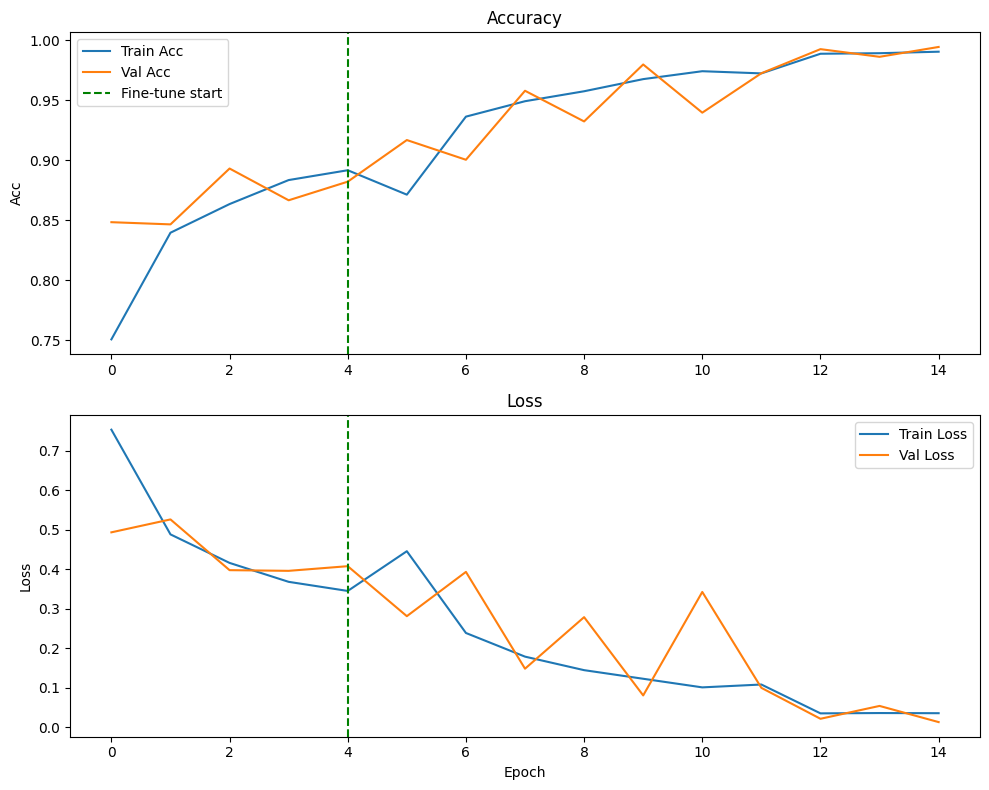

In [ ]:
acc = hist1.history['accuracy'] + hist2.history['accuracy']
val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
loss = hist1.history['loss'] + hist2.history['loss']
val_loss = hist1.history['val_loss'] + hist2.history['val_loss']

plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.plot(acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.axvline(x=initial_epochs-1, color='green', linestyle='--', label='Fine-tune start')
plt.legend(); plt.ylabel('Acc'); plt.title('Accuracy')

plt.subplot(2,1,2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.axvline(x=initial_epochs-1, color='green', linestyle='--')
plt.legend(); plt.ylabel('Loss'); plt.xlabel('Epoch'); plt.title('Loss')
plt.tight_layout(); plt.show()


first image to print
first image actual label: Tomato___Bacterial_spot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step
predicted label Tomato___Bacterial_spot


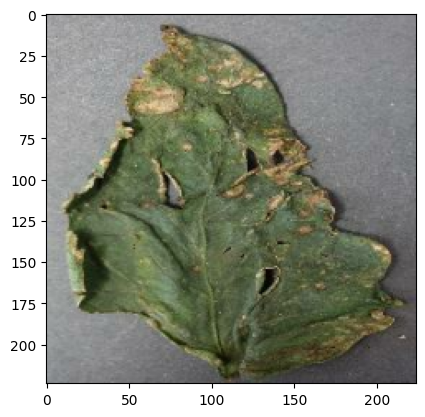

In [ ]:
for image_batch,label_batch in test_ds.take(1):
    first_image = (image_batch[0].numpy()).astype('uint8')
    first_label = label_batch[0].numpy()
    print("first image to print")
    plt.imshow(first_image)
    print("first image actual label:",class_names[first_label])
    batch_prediction = model.predict(image_batch)
    print("predicted label",class_names[np.argmax(batch_prediction[0])])

In [ ]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img, )
    img_array = tf.expand_dims(img_array, 0)
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


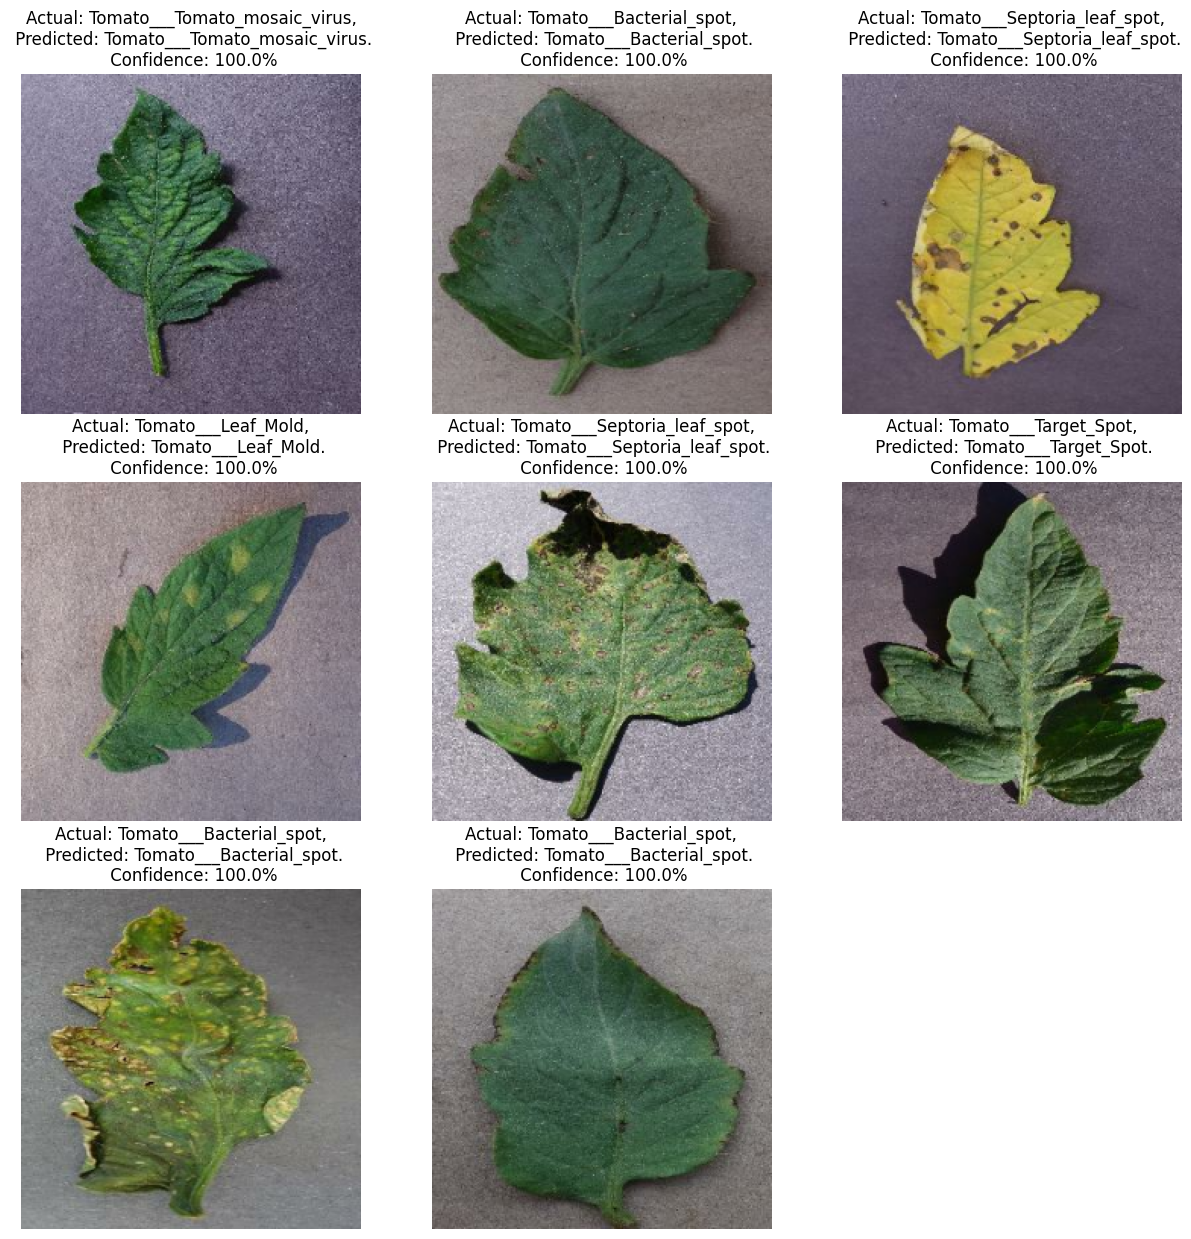

In [ ]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(BATCH_SIZE):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow((images[i].numpy()).astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis("off")

In [ ]:
y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds_classes = np.argmax(preds, axis=1)
    true_classes = labels.numpy()


    y_true.extend(true_classes)
    y_pred.extend(preds_classes)
    y_prob.extend(preds)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

**Accuracy**

In [ ]:
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")

Accuracy: 99.64%


**Precision**

In [ ]:
precision = precision_score(y_true, y_pred, average='weighted')  # or 'macro', 'micro'
print(f"Precision: {precision * 100:.2f}%")

Precision: 99.64%


**Recall**

In [ ]:
recall = recall_score(y_true, y_pred, average='weighted')
print(f"Recall: {recall * 100:.2f}%")

Recall: 99.64%


**F1 Score**

In [ ]:
f1 = f1_score(y_true, y_pred, average='weighted')
print(f"f1: {f1 * 100:.2f}%")

f1: 99.64%


**Confusion Matrix**

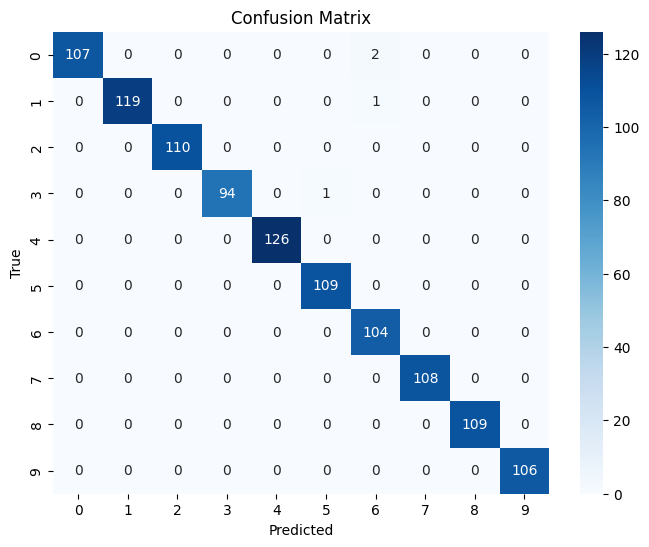

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


**AUROC**

In [ ]:
from sklearn.metrics import roc_auc_score

try:
    auc_score = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro') * 100
    print(f"Macro-Averaged ROC-AUC Score: {auc_score:.2f}%")
except Exception as e:
    print("ROC AUC not available:", e)

Macro-Averaged ROC-AUC Score: 100.00%


In [ ]:
model.save('tomato-leaf-disease_ResNet50_model.keras')

print("Model saved successfully!")

Model saved successfully!
